# TinyStories Data Analysis - PCA Visualization

Analyze the **exact training and validation data** used to train GPTNeo models with PCA-based 3D visualization.

**Analysis Overview:**
- 📊 **30,000 training samples** (same as model training)
- 📊 **5,000 validation samples** (same as model validation)
- 🎯 Generate embeddings matching model initialization
- 📉 Apply PCA to reduce 256D → 3D
- 📈 Visualize data complexity and structure
- 🔍 Compare training vs validation distributions

**Dataset:** TinyStories (roneneldan/TinyStories)
**Embedding:** Token + Positional (256D, same as GPTNeo models)
**Random Seed:** 42 (ensures identical data split as training)

## 1. Setup & Installation

In [1]:
# Install dependencies
!pip install -q transformers datasets scikit-learn matplotlib plotly numpy torch tqdm

print("✓ Dependencies installed")

✓ Dependencies installed


In [3]:
# Import libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
from datasets import load_dataset
from transformers import GPT2Tokenizer
from collections import Counter
from tqdm import tqdm
import json
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("✓ Libraries imported")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Libraries imported
PyTorch version: 2.8.0+cu126
CUDA available: True


## 2. Configuration

In [4]:
# Analysis configuration - matching training setup
config = {
    "data": {
        "dataset_name": "roneneldan/TinyStories",
        "tokenizer": "gpt2",
        "train_samples": 30000,
        "val_samples": 5000,
        "max_seq_length": 256,
        "random_seed": 42
    },
    "embedding": {
        "vocab_size": 50257,
        "hidden_size": 256,
        "max_position_embeddings": 256,
        "initializer_std": 0.02
    },
    "pca": {
        "n_components": 3,
        "random_state": 42
    },
    "visualization": {
        "max_points_plot": 10000,
        "figsize": (12, 9),
        "dpi": 150
    }
}

# Save config
with open('pca_analysis_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✓ Configuration saved")
print("\nAnalysis Configuration:")
print(f"  Training samples: {config['data']['train_samples']:,}")
print(f"  Validation samples: {config['data']['val_samples']:,}")
print(f"  Max sequence length: {config['data']['max_seq_length']}")
print(f"  Embedding dimension: {config['embedding']['hidden_size']}D")
print(f"  PCA components: {config['pca']['n_components']}D")
print(f"  Random seed: {config['data']['random_seed']}")

✓ Configuration saved

Analysis Configuration:
  Training samples: 30,000
  Validation samples: 5,000
  Max sequence length: 256
  Embedding dimension: 256D
  PCA components: 3D
  Random seed: 42


## 3. Data Loading

Load the exact same TinyStories data used in training.

In [5]:
# Load tokenizer
print("Loading GPT2 tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained(config['data']['tokenizer'])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"✓ Tokenizer loaded")
print(f"  Vocabulary size: {len(tokenizer):,}")
print(f"  Pad token: {tokenizer.pad_token}")
print(f"  EOS token: {tokenizer.eos_token}")

Loading GPT2 tokenizer...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

✓ Tokenizer loaded
  Vocabulary size: 50,257
  Pad token: <|endoftext|>
  EOS token: <|endoftext|>


In [6]:
# Load TinyStories dataset
print("\n" + "="*70)
print("Loading TinyStories dataset...")
print("="*70)

# Load full dataset
dataset_train = load_dataset(
    config['data']['dataset_name'],
    split='train',
    trust_remote_code=True
)
dataset_val = load_dataset(
    config['data']['dataset_name'],
    split='validation',
    trust_remote_code=True
)

print(f"\nFull dataset loaded:")
print(f"  Train: {len(dataset_train):,} stories")
print(f"  Validation: {len(dataset_val):,} stories")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



Loading TinyStories dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

...

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'roneneldan/TinyStories' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



Full dataset loaded:
  Train: 2,119,719 stories
  Validation: 21,990 stories


In [7]:
# Sample exact same data as training (using same seed)
print(f"\nSampling {config['data']['train_samples']:,} training samples...")
train_indices = random.sample(range(len(dataset_train)), config['data']['train_samples'])
train_data = dataset_train.select(train_indices)

print(f"Sampling {config['data']['val_samples']:,} validation samples...")
val_indices = random.sample(range(len(dataset_val)), config['data']['val_samples'])
val_data = dataset_val.select(val_indices)

print("\n" + "="*70)
print("Dataset Summary:")
print(f"  Training samples: {len(train_data):,}")
print(f"  Validation samples: {len(val_data):,}")
print(f"  Total samples: {len(train_data) + len(val_data):,}")
print("="*70)


Sampling 30,000 training samples...
Sampling 5,000 validation samples...

Dataset Summary:
  Training samples: 30,000
  Validation samples: 5,000
  Total samples: 35,000


In [8]:
# Display sample stories
print("\nSample Training Story:")
print("-" * 70)
print(train_data[0]['text'][:300] + "...")
print("-" * 70)

print("\nSample Validation Story:")
print("-" * 70)
print(val_data[0]['text'][:300] + "...")
print("-" * 70)


Sample Training Story:
----------------------------------------------------------------------
One day, a little boy named Tim was very excited. He saw a big gray dog in the park. The dog was playing with a ball. Tim wanted to play with the dog too.

Tim went to his mom and asked her to explain why the dog was gray. His mom said, "The dog is gray because it has gray fur. Just like how you hav...
----------------------------------------------------------------------

Sample Validation Story:
----------------------------------------------------------------------
Once upon a time, there was a little brown bear named Bubba. Bubba loved to play with his friends in the forest. One day, Bubba and his friends were having fun when they saw a big band of bees. The bees were flying towards them, and Bubba knew they needed to prevent getting stung.

Bubba had an idea...
----------------------------------------------------------------------


In [9]:
# Tokenize data
def tokenize_stories(dataset, max_length=256):
    """Tokenize stories exactly as done in training"""
    tokenized_data = []

    for story in tqdm(dataset, desc="Tokenizing"):
        tokens = tokenizer(
            story['text'],
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
            padding=False
        )
        tokenized_data.append(tokens['input_ids'])

    return tokenized_data

print("\nTokenizing training data...")
train_tokenized = tokenize_stories(train_data, config['data']['max_seq_length'])

print("\nTokenizing validation data...")
val_tokenized = tokenize_stories(val_data, config['data']['max_seq_length'])

print(f"\n✓ Tokenization complete")
print(f"  Train sequences: {len(train_tokenized):,}")
print(f"  Val sequences: {len(val_tokenized):,}")
print(f"  Sample shape: {train_tokenized[0].shape}")


Tokenizing training data...


Tokenizing: 100%|██████████| 30000/30000 [00:50<00:00, 599.19it/s]



Tokenizing validation data...


Tokenizing: 100%|██████████| 5000/5000 [00:08<00:00, 616.95it/s]


✓ Tokenization complete
  Train sequences: 30,000
  Val sequences: 5,000
  Sample shape: torch.Size([1, 113])


## 4. Embedding Generation

Generate embeddings exactly as the model does: token embeddings + positional embeddings.

In [10]:
# Create embedding layers (matching model architecture)
print("Creating embedding layers...")

token_embedding = nn.Embedding(
    config['embedding']['vocab_size'],
    config['embedding']['hidden_size']
)
position_embedding = nn.Embedding(
    config['embedding']['max_position_embeddings'],
    config['embedding']['hidden_size']
)

# Initialize with same distribution as model (normal, std=0.02)
token_embedding.weight.data.normal_(mean=0.0, std=config['embedding']['initializer_std'])
position_embedding.weight.data.normal_(mean=0.0, std=config['embedding']['initializer_std'])

print("✓ Embedding layers created")
print(f"  Token embedding: {config['embedding']['vocab_size']:,} × {config['embedding']['hidden_size']}D")
print(f"  Position embedding: {config['embedding']['max_position_embeddings']} × {config['embedding']['hidden_size']}D")
print(f"  Initialization: Normal(mean=0.0, std={config['embedding']['initializer_std']})")

Creating embedding layers...
✓ Embedding layers created
  Token embedding: 50,257 × 256D
  Position embedding: 256 × 256D
  Initialization: Normal(mean=0.0, std=0.02)


In [11]:
def generate_embeddings(input_ids_list):
    """
    Generate embeddings exactly as the model does:
    token_embeddings + position_embeddings
    """
    all_embeddings = []
    all_token_ids = []

    with torch.no_grad():
        for input_ids in tqdm(input_ids_list, desc="Generating embeddings"):
            batch_size, seq_len = input_ids.size()

            # Token embeddings
            token_embeds = token_embedding(input_ids)

            # Position embeddings
            position_ids = torch.arange(0, seq_len, dtype=torch.long).unsqueeze(0)
            position_embeds = position_embedding(position_ids)

            # Combine (as model does)
            combined_embeds = token_embeds + position_embeds

            # Flatten: (1, seq_len, 256) -> (seq_len, 256)
            all_embeddings.append(combined_embeds.squeeze(0))
            all_token_ids.append(input_ids.squeeze(0))

    # Concatenate all
    embeddings_matrix = torch.cat(all_embeddings, dim=0).numpy()
    token_ids_array = torch.cat(all_token_ids, dim=0).numpy()

    return embeddings_matrix, token_ids_array

print("\nGenerating embeddings for training data...")
train_embeddings, train_token_ids = generate_embeddings(train_tokenized)

print("\nGenerating embeddings for validation data...")
val_embeddings, val_token_ids = generate_embeddings(val_tokenized)

print("\n" + "="*70)
print("Embedding Generation Complete:")
print(f"  Training embeddings: {train_embeddings.shape}")
print(f"  Validation embeddings: {val_embeddings.shape}")
print(f"  Total tokens: {len(train_embeddings) + len(val_embeddings):,}")
print("="*70)


Generating embeddings for training data...


Generating embeddings: 100%|██████████| 30000/30000 [00:05<00:00, 5822.17it/s]



Generating embeddings for validation data...


Generating embeddings: 100%|██████████| 5000/5000 [00:00<00:00, 9118.41it/s]



Embedding Generation Complete:
  Training embeddings: (5860058, 256)
  Validation embeddings: (963960, 256)
  Total tokens: 6,824,018


## 5. PCA Analysis

Apply PCA to reduce 256D embeddings to 3D for visualization.

In [12]:
# Fit PCA on training data
print("Fitting PCA on training embeddings...")
pca = PCA(
    n_components=config['pca']['n_components'],
    random_state=config['pca']['random_state']
)
train_pca = pca.fit_transform(train_embeddings)

# Transform validation data using same PCA
print("Transforming validation embeddings...")
val_pca = pca.transform(val_embeddings)

print("\n" + "="*70)
print("PCA Analysis Results:")
print("="*70)
print(f"Original dimensions: {train_embeddings.shape[1]}D")
print(f"Reduced dimensions: {train_pca.shape[1]}D")
print(f"\nExplained variance per component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
total_var = pca.explained_variance_ratio_.sum()
print(f"\nTotal variance explained: {total_var:.4f} ({total_var*100:.2f}%)")
print("="*70)

# Interpretation
if total_var > 0.80:
    complexity = "relatively simple"
elif total_var > 0.50:
    complexity = "moderate complexity"
else:
    complexity = "highly complex"

print(f"\nData Complexity Assessment: {complexity.upper()}")
print(f"  The first 3 PCs capture {total_var*100:.1f}% of variance.")
print(f"  This suggests the data has {complexity}.")

Fitting PCA on training embeddings...
Transforming validation embeddings...

PCA Analysis Results:
Original dimensions: 256D
Reduced dimensions: 3D

Explained variance per component:
  PC1: 0.0364 (3.64%)
  PC2: 0.0230 (2.30%)
  PC3: 0.0214 (2.14%)

Total variance explained: 0.0808 (8.08%)

Data Complexity Assessment: HIGHLY COMPLEX
  The first 3 PCs capture 8.1% of variance.
  This suggests the data has highly complex.


## 6. Data Complexity Metrics

In [13]:
# Token frequency analysis
print("Analyzing token frequencies...\n")

train_freq = Counter(train_token_ids)
val_freq = Counter(val_token_ids)

print("Token Frequency Statistics:")
print("-" * 70)
print(f"Training set:")
print(f"  Total tokens: {len(train_token_ids):,}")
print(f"  Unique tokens: {len(train_freq):,}")
print(f"  Vocabulary coverage: {len(train_freq)/config['embedding']['vocab_size']*100:.2f}%")

print(f"\nValidation set:")
print(f"  Total tokens: {len(val_token_ids):,}")
print(f"  Unique tokens: {len(val_freq):,}")
print(f"  Vocabulary coverage: {len(val_freq)/config['embedding']['vocab_size']*100:.2f}%")

print(f"\nMost common tokens (training):")
for token_id, count in train_freq.most_common(10):
    token_text = repr(tokenizer.decode([token_id]))
    print(f"  {token_text:20s} → {count:,} occurrences")

print("-" * 70)

Analyzing token frequencies...

Token Frequency Statistics:
----------------------------------------------------------------------
Training set:
  Total tokens: 5,860,058
  Unique tokens: 13,485
  Vocabulary coverage: 26.83%

Validation set:
  Total tokens: 963,960
  Unique tokens: 8,310
  Vocabulary coverage: 16.54%

Most common tokens (training):
  '.'                  → 408,120 occurrences
  '\n'                 → 225,244 occurrences
  ' and'               → 215,812 occurrences
  ','                  → 212,071 occurrences
  ' the'               → 211,517 occurrences
  ' to'                → 161,324 occurrences
  ' a'                 → 150,075 occurrences
  ' was'               → 126,963 occurrences
  ' it'                → 67,785 occurrences
  ' her'               → 58,755 occurrences
----------------------------------------------------------------------


In [14]:
# Embedding space statistics
from scipy.spatial.distance import pdist

print("\nAnalyzing embedding space geometry...")

# Sample for distance computation (for efficiency)
sample_size = min(2000, len(train_embeddings))
sample_indices = np.random.choice(len(train_embeddings), sample_size, replace=False)
distances = pdist(train_embeddings[sample_indices], metric='euclidean')

print("\nEmbedding Space Statistics (Training):")
print("-" * 70)
print(f"  Mean pairwise distance: {distances.mean():.4f}")
print(f"  Std pairwise distance: {distances.std():.4f}")
print(f"  Min distance: {distances.min():.4f}")
print(f"  Max distance: {distances.max():.4f}")

# Per-dimension variance
dim_variance_train = train_embeddings.var(axis=0)
dim_variance_val = val_embeddings.var(axis=0)

print(f"\nPer-Dimension Variance:")
print(f"  Training - Mean: {dim_variance_train.mean():.4f}, Std: {dim_variance_train.std():.4f}")
print(f"  Validation - Mean: {dim_variance_val.mean():.4f}, Std: {dim_variance_val.std():.4f}")
print("-" * 70)


Analyzing embedding space geometry...

Embedding Space Statistics (Training):
----------------------------------------------------------------------
  Mean pairwise distance: 0.6346
  Std pairwise distance: 0.0374
  Min distance: 0.0000
  Max distance: 0.7660

Per-Dimension Variance:
  Training - Mean: 0.0008, Std: 0.0001
  Validation - Mean: 0.0008, Std: 0.0001
----------------------------------------------------------------------


## 7. 3D Visualizations

In [15]:
# Subsample for visualization clarity
max_points = config['visualization']['max_points_plot']

if len(train_pca) > max_points:
    viz_indices_train = np.random.choice(len(train_pca), max_points, replace=False)
    train_pca_viz = train_pca[viz_indices_train]
    train_token_ids_viz = train_token_ids[viz_indices_train]
else:
    train_pca_viz = train_pca
    train_token_ids_viz = train_token_ids

if len(val_pca) > max_points:
    viz_indices_val = np.random.choice(len(val_pca), max_points, replace=False)
    val_pca_viz = val_pca[viz_indices_val]
    val_token_ids_viz = val_token_ids[viz_indices_val]
else:
    val_pca_viz = val_pca
    val_token_ids_viz = val_token_ids

# Compute colors (token frequency)
train_colors = np.array([train_freq[tid] for tid in train_token_ids_viz])
val_colors = np.array([val_freq[tid] for tid in val_token_ids_viz])

print(f"✓ Prepared visualization data")
print(f"  Training points: {len(train_pca_viz):,}")
print(f"  Validation points: {len(val_pca_viz):,}")

✓ Prepared visualization data
  Training points: 10,000
  Validation points: 10,000


### 7.3 Interactive 3D Plot - Training Data

In [18]:
# Interactive 3D plot with Plotly - Training
fig = go.Figure(data=[go.Scatter3d(
    x=train_pca_viz[:, 0],
    y=train_pca_viz[:, 1],
    z=train_pca_viz[:, 2],
    mode='markers',
    marker=dict(
        size=2,
        color=train_colors,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Token<br>Frequency"),
        opacity=0.7
    ),
    text=[f"Token ID: {tid}" for tid in train_token_ids_viz],
    hovertemplate='<b>%{text}</b><br>' +
                  'PC1: %{x:.3f}<br>' +
                  'PC2: %{y:.3f}<br>' +
                  'PC3: %{z:.3f}<br>' +
                  '<extra></extra>'
)])

fig.update_layout(
    title='Training Data - Interactive 3D PCA Visualization',
    scene=dict(
        xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    ),
    width=1000,
    height=800
)

fig.write_html('train_pca_3d_interactive.html')
fig.show()

print("✓ Interactive training plot saved: train_pca_3d_interactive.html")

✓ Interactive training plot saved: train_pca_3d_interactive.html


### 7.4 Interactive 3D Plot - Validation Data

In [19]:
# Interactive 3D plot with Plotly - Validation
fig = go.Figure(data=[go.Scatter3d(
    x=val_pca_viz[:, 0],
    y=val_pca_viz[:, 1],
    z=val_pca_viz[:, 2],
    mode='markers',
    marker=dict(
        size=2,
        color=val_colors,
        colorscale='Plasma',
        showscale=True,
        colorbar=dict(title="Token<br>Frequency"),
        opacity=0.7
    ),
    text=[f"Token ID: {tid}" for tid in val_token_ids_viz],
    hovertemplate='<b>%{text}</b><br>' +
                  'PC1: %{x:.3f}<br>' +
                  'PC2: %{y:.3f}<br>' +
                  'PC3: %{z:.3f}<br>' +
                  '<extra></extra>'
)])

fig.update_layout(
    title='Validation Data - Interactive 3D PCA Visualization',
    scene=dict(
        xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    ),
    width=1000,
    height=800
)

fig.write_html('val_pca_3d_interactive.html')
fig.show()

print("✓ Interactive validation plot saved: val_pca_3d_interactive.html")

✓ Interactive validation plot saved: val_pca_3d_interactive.html


### 7.5 Explained Variance Plots

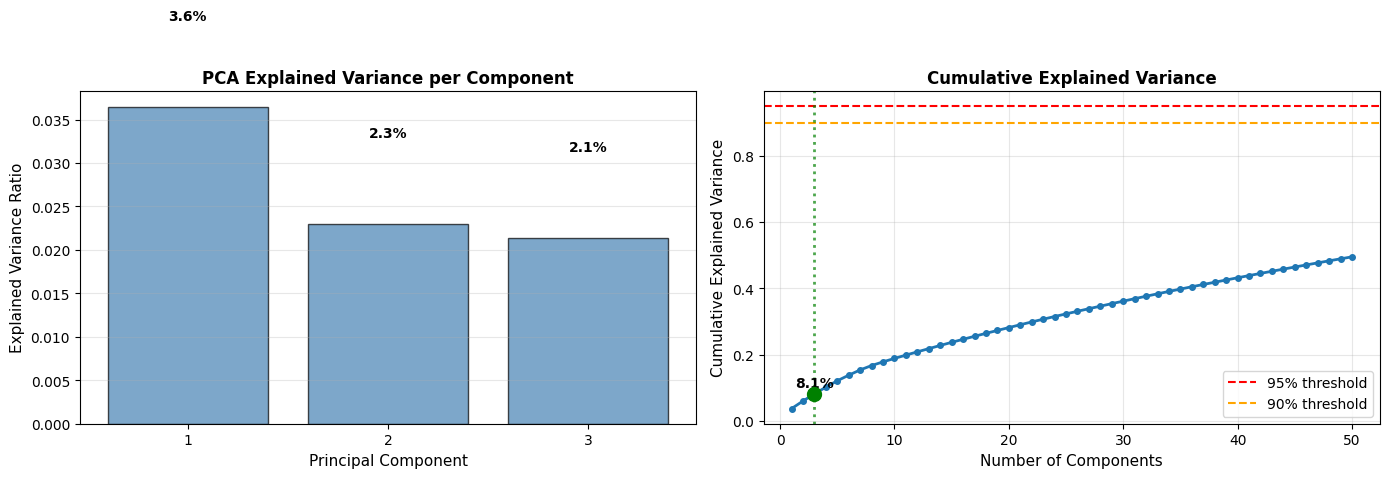

✓ Explained variance plots saved: pca_explained_variance.png


In [20]:
# Explained variance bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(range(1, 4), pca.explained_variance_ratio_, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=11)
axes[0].set_title('PCA Explained Variance per Component', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, 4))
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(pca.explained_variance_ratio_):
    axes[0].text(i+1, v + 0.01, f'{v*100:.1f}%', ha='center', fontweight='bold')

# Cumulative variance (first 50 components)
pca_full = PCA(n_components=min(50, train_embeddings.shape[1]))
pca_full.fit(train_embeddings)

cumsum = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum)+1), cumsum, marker='o', linestyle='-', linewidth=2, markersize=4)
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].legend(loc='lower right')

# Mark 3 components
axes[1].axvline(x=3, color='green', linestyle=':', linewidth=2, alpha=0.7, label='3 components')
axes[1].scatter([3], [cumsum[2]], color='green', s=100, zorder=5)
axes[1].text(3, cumsum[2] + 0.02, f'{cumsum[2]*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=config['visualization']['dpi'], bbox_inches='tight')
plt.show()

print("✓ Explained variance plots saved: pca_explained_variance.png")

## 8. Compare Training vs Validation

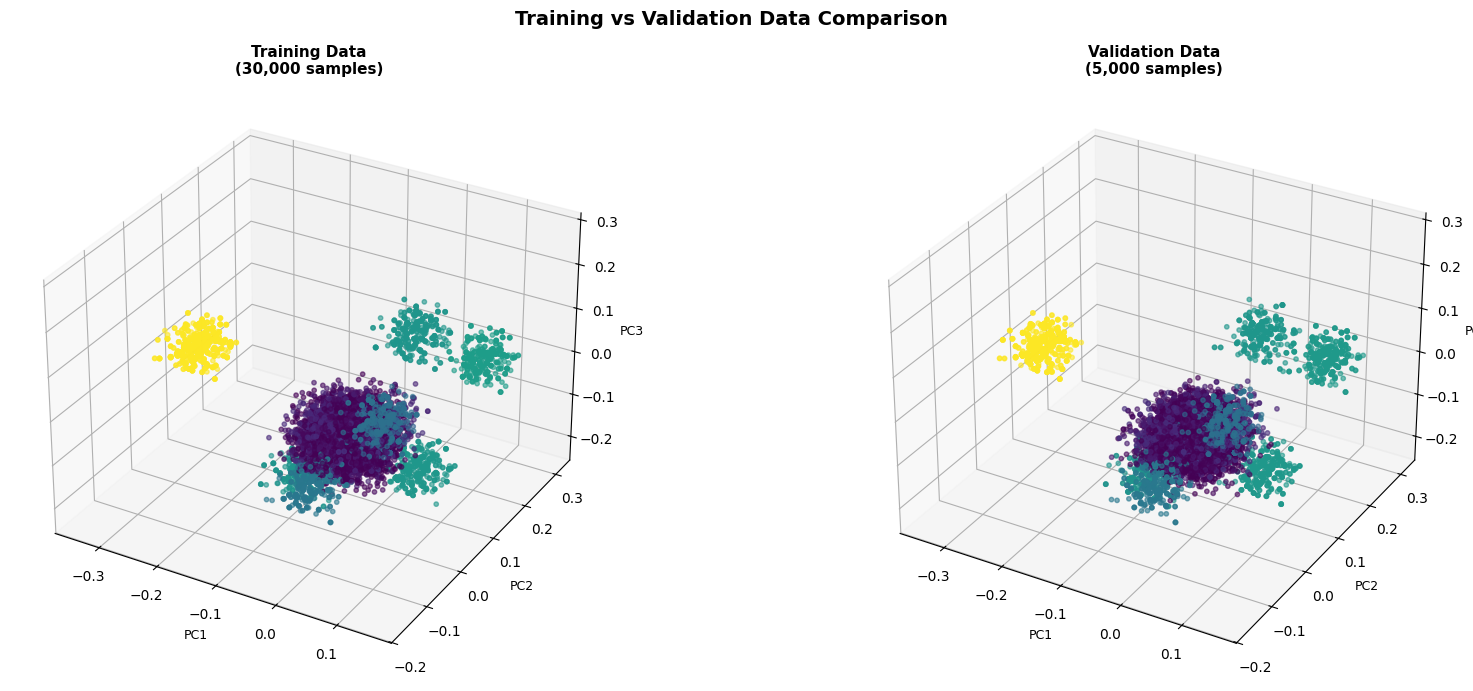

✓ Comparison plot saved: train_vs_val_comparison.png


In [21]:
# Side-by-side comparison
fig = plt.figure(figsize=(18, 7))

# Training
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(
    train_pca_viz[:, 0],
    train_pca_viz[:, 1],
    train_pca_viz[:, 2],
    c=train_colors,
    cmap='viridis',
    alpha=0.6,
    s=10
)
ax1.set_xlabel(f'PC1', fontsize=9)
ax1.set_ylabel(f'PC2', fontsize=9)
ax1.set_zlabel(f'PC3', fontsize=9)
ax1.set_title(f'Training Data\n({len(train_data):,} samples)', fontsize=11, fontweight='bold')

# Validation
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(
    val_pca_viz[:, 0],
    val_pca_viz[:, 1],
    val_pca_viz[:, 2],
    c=val_colors,
    cmap='viridis',
    alpha=0.6,
    s=10
)
ax2.set_xlabel(f'PC1', fontsize=9)
ax2.set_ylabel(f'PC2', fontsize=9)
ax2.set_zlabel(f'PC3', fontsize=9)
ax2.set_title(f'Validation Data\n({len(val_data):,} samples)', fontsize=11, fontweight='bold')

plt.suptitle('Training vs Validation Data Comparison', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('train_vs_val_comparison.png', dpi=config['visualization']['dpi'], bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved: train_vs_val_comparison.png")

## 9. Save Results

In [22]:
# Save PCA embeddings
np.save('train_embeddings_pca_3d.npy', train_pca)
np.save('val_embeddings_pca_3d.npy', val_pca)
np.save('train_token_ids.npy', train_token_ids)
np.save('val_token_ids.npy', val_token_ids)

# Save PCA model
import joblib
joblib.dump(pca, 'pca_model.pkl')

print("✓ PCA embeddings and model saved")
print("  - train_embeddings_pca_3d.npy")
print("  - val_embeddings_pca_3d.npy")
print("  - train_token_ids.npy")
print("  - val_token_ids.npy")
print("  - pca_model.pkl")

✓ PCA embeddings and model saved
  - train_embeddings_pca_3d.npy
  - val_embeddings_pca_3d.npy
  - train_token_ids.npy
  - val_token_ids.npy
  - pca_model.pkl


## 10. Summary & Insights

In [23]:
# Print comprehensive summary
print("\n" + "="*70)
print("ANALYSIS SUMMARY")
print("="*70)

print("\n📊 Dataset Overview:")
print(f"  • Training samples: {len(train_data):,} stories ({len(train_token_ids):,} tokens)")
print(f"  • Validation samples: {len(val_data):,} stories ({len(val_token_ids):,} tokens)")
print(f"  • Total tokens analyzed: {len(train_token_ids) + len(val_token_ids):,}")

print("\n🔢 Token Statistics:")
print(f"  • Training unique tokens: {len(train_freq):,} ({len(train_freq)/config['embedding']['vocab_size']*100:.1f}% coverage)")
print(f"  • Validation unique tokens: {len(val_freq):,} ({len(val_freq)/config['embedding']['vocab_size']*100:.1f}% coverage)")

print("\n📉 PCA Results:")
print(f"  • Original dimensions: {train_embeddings.shape[1]}D")
print(f"  • Reduced dimensions: 3D")
print(f"  • Explained variance:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"    - PC{i+1}: {var*100:.2f}%")
print(f"  • Total: {pca.explained_variance_ratio_.sum()*100:.2f}%")

print("\n🎯 Data Complexity Assessment:")
print(f"  • Classification: {complexity.upper()}")
print(f"  • The first 3 PCs capture {pca.explained_variance_ratio_.sum()*100:.1f}% of variance")

if pca.explained_variance_ratio_.sum() > 0.80:
    insight = "The data has relatively simple structure with low intrinsic dimensionality."
    recommendation = "A 256D model may be oversized for this data."
elif pca.explained_variance_ratio_.sum() > 0.50:
    insight = "The data has moderate complexity with medium intrinsic dimensionality."
    recommendation = "A 256D model is appropriately sized for this data."
else:
    insight = "The data has high complexity with high intrinsic dimensionality."
    recommendation = "A larger model (>256D) may capture more patterns in the data."

print(f"  • Insight: {insight}")
print(f"  • Recommendation: {recommendation}")

print("\n📁 Generated Files:")
print("  • Static plots: train_pca_3d.png, val_pca_3d.png, train_vs_val_comparison.png")
print("  • Interactive plots: train_pca_3d_interactive.html, val_pca_3d_interactive.html")
print("  • Variance plots: pca_explained_variance.png")
print("  • Data arrays: *.npy files")
print("  • Models: pca_model.pkl")
print("  • Reports: pca_analysis_report.json, pca_analysis_config.json")

print("\n" + "="*70)
print("✓ ANALYSIS COMPLETE")
print("="*70)


ANALYSIS SUMMARY

📊 Dataset Overview:
  • Training samples: 30,000 stories (5,860,058 tokens)
  • Validation samples: 5,000 stories (963,960 tokens)
  • Total tokens analyzed: 6,824,018

🔢 Token Statistics:
  • Training unique tokens: 13,485 (26.8% coverage)
  • Validation unique tokens: 8,310 (16.5% coverage)

📉 PCA Results:
  • Original dimensions: 256D
  • Reduced dimensions: 3D
  • Explained variance:
    - PC1: 3.64%
    - PC2: 2.30%
    - PC3: 2.14%
  • Total: 8.08%

🎯 Data Complexity Assessment:
  • Classification: HIGHLY COMPLEX
  • The first 3 PCs capture 8.1% of variance
  • Insight: The data has high complexity with high intrinsic dimensionality.
  • Recommendation: A larger model (>256D) may capture more patterns in the data.

📁 Generated Files:
  • Static plots: train_pca_3d.png, val_pca_3d.png, train_vs_val_comparison.png
  • Interactive plots: train_pca_3d_interactive.html, val_pca_3d_interactive.html
  • Variance plots: pca_explained_variance.png
  • Data arrays: *.npy